# Assignment 4 Visualization  

**Research Question:**  
*How does the share of renewable energy in total energy consumption influence CO₂ emissions per capita across different countries and regions?*  

This notebook fetches **live data directly from Wikipedia** (CO₂ emissions per capita and renewable electricity production), cleans it, merges it, and produces a scatterplot visualization.  


In [21]:
import pandas as pd
import urllib.request, urllib.parse, urllib.error
from bs4 import BeautifulSoup
import ssl
from io import StringIO


ctx=ssl.create_default_context()
ctx.check_hostname=False
ctx.verify_mode=ssl.CERT_NONE

# A browser-like User-Agent prevents 403 responses from Wikipedia
HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/126.0.0.0 Safari/537.36"
    )
}



def read_wikipedia_tables(url: str) -> list[pd.DataFrame]:
# Build request with User-Agent header
    req = urllib.request.Request(
        url,
        headers=HEADERS
    )
    with urllib.request.urlopen(req) as response:
        html = response.read()
    soup = BeautifulSoup(html, "html.parser")
    wikitables = soup.find_all("table", {"class": "wikitable"})
    # Convert each wikitable to a pandas DataFrame
    tables = []
    for table in wikitables:
        tables.extend(pd.read_html(str(table)))  # str(table) gives single table HTML
    return tables

# --- 1. Load CO₂ emissions per capita from Wikipedia ---
co2_url = "https://en.wikipedia.org/wiki/List_of_countries_by_carbon_dioxide_emissions_per_capita"
# Narrow down to tables styled as 'wikitable' (common on Wikipedia) and optionally match a column header
co2_tables = read_wikipedia_tables(co2_url)

# --- 2. Load Renewable electricity production from Wikipedia ---
renew_url = "https://en.wikipedia.org/wiki/List_of_countries_by_renewable_electricity_production"
renew_tables = read_wikipedia_tables(renew_url)

co2_tables

C:\Users\ksayed\AppData\Local\Temp\ipykernel_21732\285732298.py:36: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables.extend(pd.read_html(str(table)))  # str(table) gives single table HTML
C:\Users\ksayed\AppData\Local\Temp\ipykernel_21732\285732298.py:36: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables.extend(pd.read_html(str(table)))  # str(table) gives single table HTML
C:\Users\ksayed\AppData\Local\Temp\ipykernel_21732\285732298.py:36: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables.extend(pd.read_html(str(table)))  # str(table) gives single table HTML
C:\Users\ksayed\AppData\Local\Temp\ipykernel_2173

[                             Location % of global average  \
                              Location % of global average   
 0                               World                100%   
 1                      European Union                117%   
 2                          Palau[n 4]               1288%   
 3                               Qatar                896%   
 4                              Kuwait                512%   
 ..                                ...                 ...   
 205          Central African Republic                  1%   
 206                           Burundi                  1%   
 207                           Somalia                  1%   
 208                     Faroe Islands                  1%   
 209  Democratic Republic of the Congo                  1%   
 
     Emissions per capita (tons per year)         % change from 2000  
                                     2023    2000 % change from 2000  
 0                                   4.86    4.19 

In [23]:
import re
import pandas as pd
import numpy as np


def _flatten_columns(df: pd.DataFrame) -> pd.DataFrame:
    if isinstance(df.columns, pd.MultiIndex):
        flat = []
        for tup in df.columns:
            # join non-empty parts; remove 'nan' fragments
            parts = [str(x) for x in tup if pd.notna(x) and str(x).strip() != ""]
            flat.append(" ".join(parts))
        df = df.copy()
        df.columns = flat
    return df

def _normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # remove footnote markers like [1], [note 2], etc., normalize spaces, lowercase
    def clean(col: str) -> str:
        col = str(col)
        col = re.sub(r"\[[^\]]*\]", "", col)  # remove bracketed notes
        col = col.replace("\xa0", " ")
        col = re.sub(r"\s+", " ", col)
        return col.strip().lower()
    df.columns = [clean(c) for c in df.columns]
    return df

def _select_country_and_year(df: pd.DataFrame, year: str = "2020"):
    # candidates for country column
    country_candidates = [c for c in df.columns if "country" in c]
    # occasionally the column might be named "territory" only
    if not country_candidates:
        country_candidates = [c for c in df.columns if "territory" in c]
    if not country_candidates:
        raise KeyError("Could not find a 'country' column after normalization.")

    # year column candidates (contain the year string)
    year_candidates = [c for c in df.columns if year in c]
    if not year_candidates:
        raise KeyError(f"Could not find a column containing '{year}' after normalization.")

    # prefer columns that look numeric when coerced
    def numeric_score(series: pd.Series) -> float:
        vals = pd.to_numeric(series, errors="coerce")
        return float(vals.notna().mean())

    # pick first country and best year by numeric density
    country_col = country_candidates[0]
    year_col = max(year_candidates, key=lambda c: numeric_score(df[c]))

    return country_col, year_col

# If you already have co2_tables from pd.read_html(html), pick the right table.
# Sometimes the index might differ; choose the table that actually has the desired year in its columns.
def _pick_table_with_year(tables, year="2020"):
    best_idx = None
    for i, t in enumerate(tables):
        t2 = _normalize_columns(_flatten_columns(t))
        if any(year in c for c in t2.columns):
            best_idx = i
            break
    # Fallback to index 1 if not found, to match original expectation
    return tables[best_idx] if best_idx is not None else tables[1]


In [29]:
# ---- Main extraction logic ----
# co2_tables should already exist from an earlier pd.read_html call
co2_raw = _pick_table_with_year(co2_tables, year="2020")
co2_norm = _normalize_columns(_flatten_columns(co2_raw))

country_col, year_col = _select_country_and_year(co2_norm, year="2020")

co2 = co2_norm[[country_col, year_col]].rename(
    columns={country_col: "Country", year_col: "CO2_per_capita"}
)


# Clean data
co2 = co2.dropna()
co2["CO2_per_capita"] = pd.to_numeric(co2["CO2_per_capita"], errors="coerce")
co2 = co2.dropna()



# Table 0 contains renewable production
renew = renew_tables[0]
renew = renew.rename(columns={"Location": "Country", "Renew.": "Renewable_Share"})
renew = renew[["Country", "Renewable_Share"]]

# Clean renewable share
renew["Renewable_Share"] = (
    renew["Renewable_Share"].astype(str).str.replace("%", "").str.strip()
)
renew["Renewable_Share"] = pd.to_numeric(renew["Renewable_Share"], errors="coerce")
renew = renew.dropna()

# --- 3. Merge datasets on Country ---
df = pd.merge(co2, renew, on="Country", how="inner")

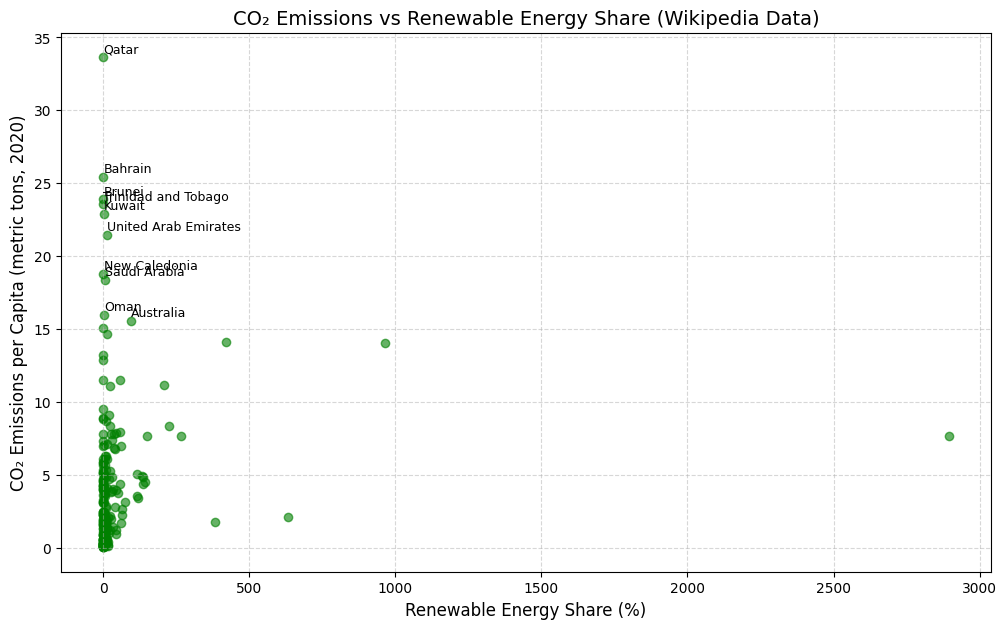

In [30]:
from matplotlib import pyplot as plt

# --- 4. Create scatter plot ---
plt.figure(figsize=(12,7))
plt.scatter(df["Renewable_Share"], df["CO2_per_capita"], color="green", alpha=0.6)

# Annotate top 10 countries for clarity
for i, row in df.nlargest(10, "CO2_per_capita").iterrows():
    plt.text(row["Renewable_Share"]+0.5, row["CO2_per_capita"]+0.3, row["Country"], fontsize=9)

plt.title("CO₂ Emissions vs Renewable Energy Share (Wikipedia Data)", fontsize=14)
plt.xlabel("Renewable Energy Share (%)", fontsize=12)
plt.ylabel("CO₂ Emissions per Capita (metric tons, 2020)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

# Save and show figure
plt.savefig("renewable_vs_co2_wikipedia.png")
plt.show()
